# VECTRI Output Analysis & Visualization

This notebook provides a comprehensive analysis of the VECTRI model output (`vectri.nc`). 
We inspect, visualize, and analyze variables across three key groups:
1. **Vector** (Mosquito population dynamics)
2. **Disease** (Transmission metrics)
3. **Hydrology** (Water fraction/pond dynamics)

## 1. Setup & Data Loading

In [46]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import geopandas as gpd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import rioxarray as rio
import os

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]

# Define the output folder for figures
OUTPUT_FOLDER = r'C:\Users\yonas\Documents\VECTRI-PYTHON\notebooks\output_figures'
if not os.path.exists(OUTPUT_FOLDER):
    os.makedirs(OUTPUT_FOLDER)


In [47]:
# Load the dataset
FILE_PATH = r'C:\Users\yonas\Documents\VECTRI-PYTHON\experment1.nc'
FILE_PATH

'C:\\Users\\yonas\\Documents\\VECTRI-PYTHON\\experment1.nc'

In [48]:
try:
    ds_vector = xr.open_dataset(FILE_PATH, group="vector")
    print("Dataset loaded successfully.")
    print(ds_vector)
except Exception as e:
    print(f"Error loading dataset: {e}")

Dataset loaded successfully.
<xarray.Dataset> Size: 690MB
Dimensions:    (time: 10958, latitude: 57, longitude: 69)
Dimensions without coordinates: time, latitude, longitude
Data variables:
    vector     (time, latitude, longitude) float32 172MB ...
    larvae     (time, latitude, longitude) float32 172MB ...
    emergence  (time, latitude, longitude) float32 172MB ...
    hbr        (time, latitude, longitude) float32 172MB ...


## General Inspection
Overview of dimensions, coordinates, and available variables.

In [49]:
if 'ds_vector' in locals():
    print("Dimensions:", dict(ds_vector.dims))
    print("\nVariables:", list(ds_vector.data_vars))
    
    # Check time range
    if 'time' in ds_vector.coords:
        print(f"\nTime Range: {ds_vector.time.min().values} to {ds_vector.time.max().values}")

Dimensions: {'time': 10958, 'latitude': 57, 'longitude': 69}

Variables: ['vector', 'larvae', 'emergence', 'hbr']


C:\Users\yonas\AppData\Local\Temp\ipykernel_24832\2210244360.py:2: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print("Dimensions:", dict(ds_vector.dims))


In [50]:
ds_precip.time.values

array(['1991-01-01T00:00:00.000000000', '1991-01-02T00:00:00.000000000',
       '1991-01-03T00:00:00.000000000', ...,
       '2020-12-29T00:00:00.000000000', '2020-12-30T00:00:00.000000000',
       '2020-12-31T00:00:00.000000000'],
      shape=(10958,), dtype='datetime64[ns]')

In [51]:
ds_precip = xr.open_dataset(r'C:\Users\yonas\Documents\VECTRI-PYTHON\data\processed\precip_processed.nc')
latitudes = ds_precip.latitude.values
longitudes = ds_precip.longitude.values
time_values = ds_precip.time.values

In [52]:
# Define the path to your shapefile
shapefile = r'C:\Users\yonas\Documents\VECTRI-PYTHON\ETH_Admins_2024\ETH_Regions.shp'




## Vector Analysis (Mosquito Density)
Visualizing mosquito larvae and adult populations.
*Variables*: Look for `vector` related vars (e.g., `larvae`, `vector`). *Note: Variable names need confirmation from dataset print above.*

In [53]:
def plot_spatial_map(ds, var_name, title, lats=None, lons=None, shapefile_path=None):
    """Plots a smoothed spatial map of the time-averaged value of a variable, clipped to a shapefile."""
    if var_name in ds:
        ds_to_plot = ds.copy()
        if lats is not None:
            ds_to_plot.coords['latitude'] = lats
        if lons is not None:
            ds_to_plot.coords['longitude'] = lons

        # Spatial distribution (Time Average)
        avg_map = ds_to_plot[var_name].mean(dim='time')
        
        # Create a higher-resolution grid for interpolation
        new_lons = np.linspace(avg_map.longitude.min().item(), avg_map.longitude.max().item(), 300)
        new_lats = np.linspace(avg_map.latitude.min().item(), avg_map.latitude.max().item(), 300)

        # Interpolate to smooth the data
        smoothed_map = avg_map.interp(longitude=new_lons, latitude=new_lats, method='cubic')
        
        # Add CRS information to the smoothed DataArray
        smoothed_map.rio.write_crs("epsg:4326", inplace=True)

        if shapefile_path:
            # Load the shapefile
            gdf = gpd.read_file(shapefile_path)
            
            # Clip the smoothed data to the shapefile
            clipped_map = smoothed_map.rio.clip(gdf.geometry, gdf.crs, drop=False)
        else:
            clipped_map = smoothed_map

        # Create the plot with a specific map projection
        fig = plt.figure(figsize=(12, 10))
        ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
        
        # Plot the smoothed and clipped data
        clipped_map.plot(ax=ax, x='longitude', y='latitude', cmap='viridis', 
                          transform=ccrs.PlateCarree(), add_colorbar=True,
                          cbar_kwargs={'shrink': 0.6})

        if shapefile_path:
            # Add the shapefile to the plot for boundary visualization
            ax.add_geometries(gdf['geometry'], crs=ccrs.PlateCarree(), facecolor='none', edgecolor='black')

        # Add map features
        ax.coastlines()
        ax.add_feature(cfeature.BORDERS, linestyle=':')
        
        # Set title and labels
        ax.set_title(f"{title} (Time-Averaged)")
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
        
        # Save the figure
        file_name = f"spatial_map_{var_name}.png"
        plt.savefig(os.path.join(OUTPUT_FOLDER, file_name))
        
        plt.show()
    else:
        print(f"Variable '{var_name}' not found.")


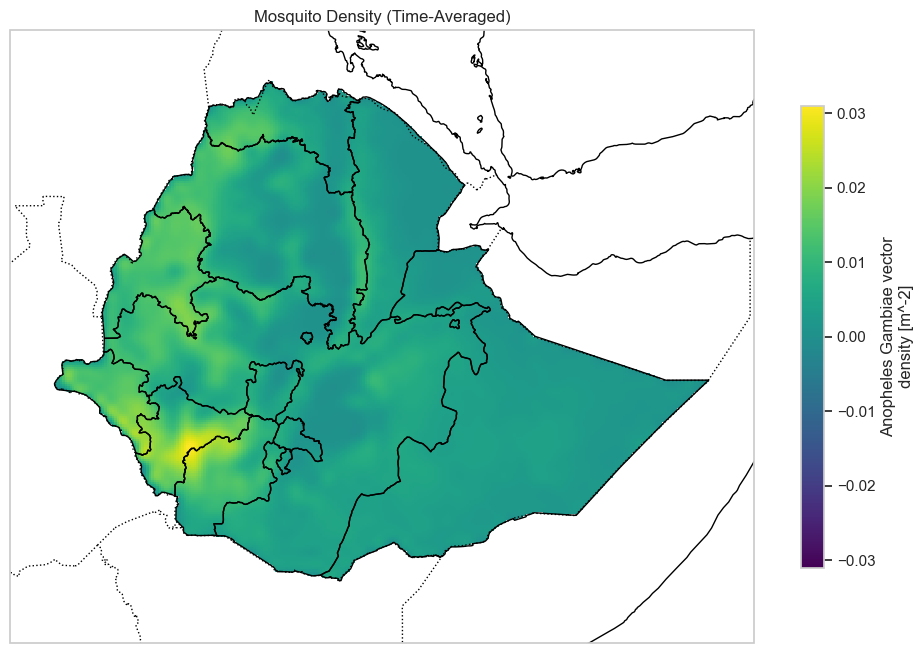

In [54]:

# Plot spatial map
plot_spatial_map(ds_vector, var_name='vector', title='Mosquito Density', lats=latitudes, lons=longitudes, shapefile_path=shapefile)

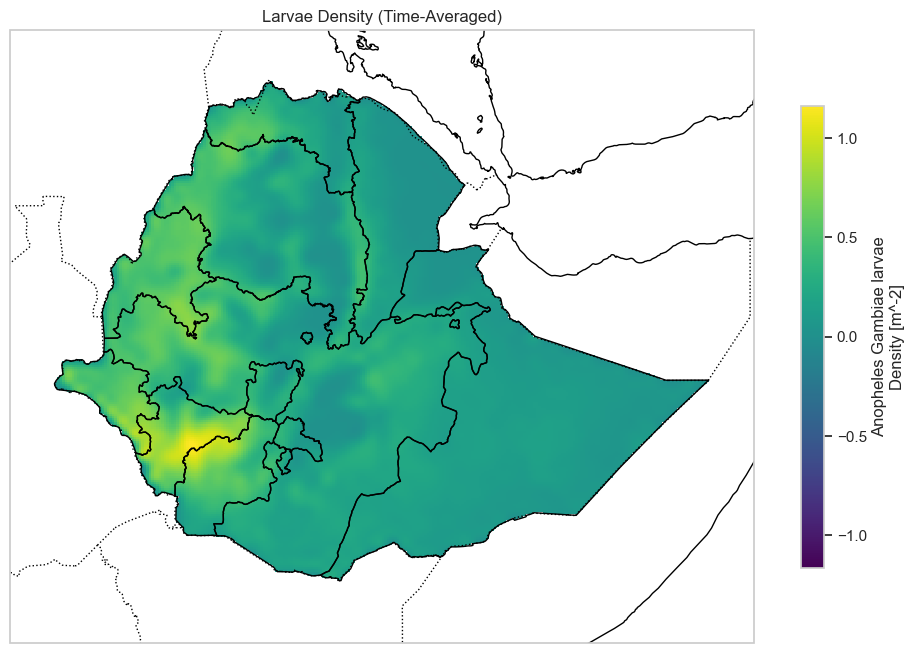

In [55]:
# Plot spatial map
plot_spatial_map(ds_vector, var_name='larvae', title='Larvae Density', lats=latitudes, lons=longitudes, shapefile_path=shapefile)

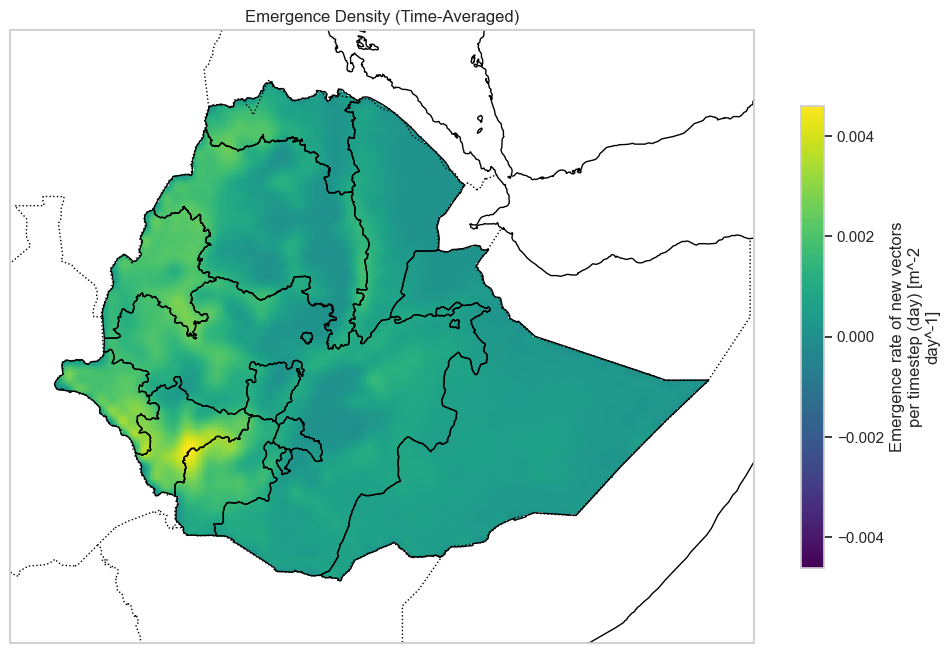

In [56]:
# Plot spatial map
plot_spatial_map(ds_vector, var_name='emergence', title='Emergence Density', lats=latitudes, lons=longitudes, shapefile_path=shapefile)

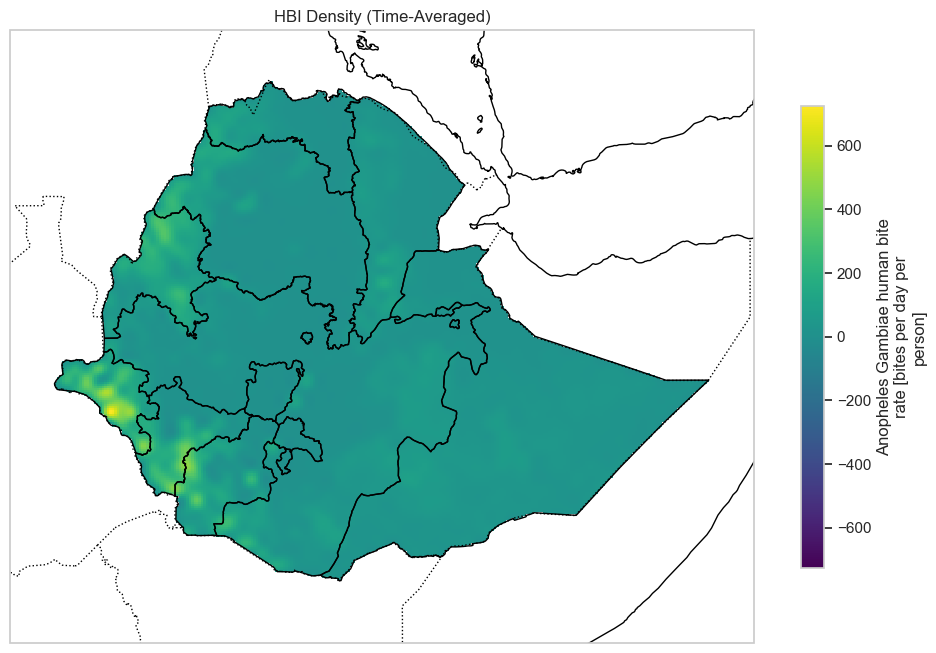

In [57]:
plot_spatial_map(ds_vector, var_name='hbr', title='HBI Density', lats=latitudes, lons=longitudes, shapefile_path=shapefile)

## Spatially Averaged Mosquito Density

In [58]:
def plot_temporal_series(ds, var_name, title, time_coords=None):
    """Plots a time series of the spatially-averaged value of a variable."""
    if var_name in ds:
        ds_to_plot = ds.copy()
        if time_coords is not None:
            # Ensure time coordinates are assigned correctly
            if len(time_coords) == len(ds_to_plot['time']):
                ds_to_plot = ds_to_plot.assign_coords(time=time_coords)
            else:
                print("Warning: Length of time_coords does not match length of time dimension.")
                return

        # Time Series (Spatial Average)
        spatial_mean = ds_to_plot[var_name].mean(dim=['latitude', 'longitude'], keep_attrs=True)
        
        plt.figure(figsize=(12, 5))
        spatial_mean.plot()
        plt.title(f"{title} (Spatially Averaged Time Series)")
        plt.ylabel(ds_to_plot[var_name].attrs.get('units', 'Value'))
        
        # Save the figure
        file_name = f"temporal_series_{var_name}.png"
        plt.savefig(os.path.join(OUTPUT_FOLDER, file_name))
        
        plt.show()
    else:
        print(f"Variable '{var_name}' not found.")


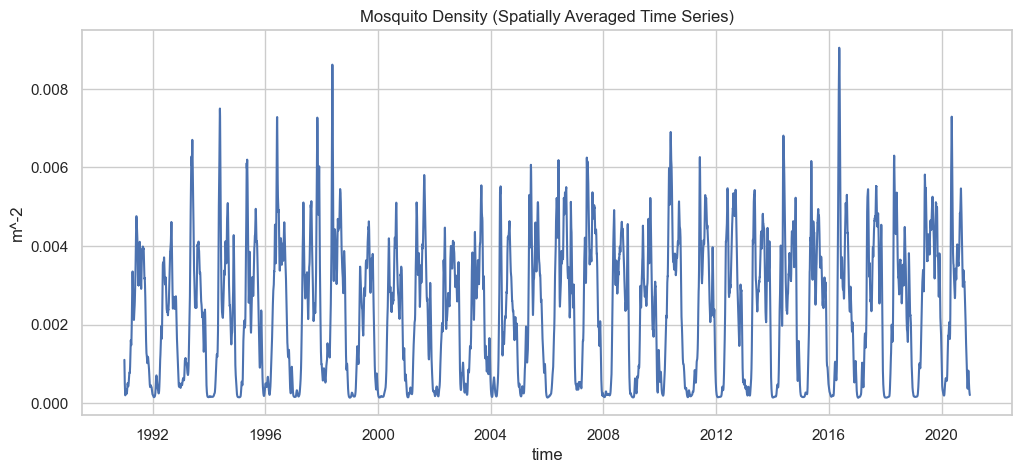

In [59]:
plot_temporal_series(ds_vector, var_name='vector', title='Mosquito Density', time_coords=time_values)

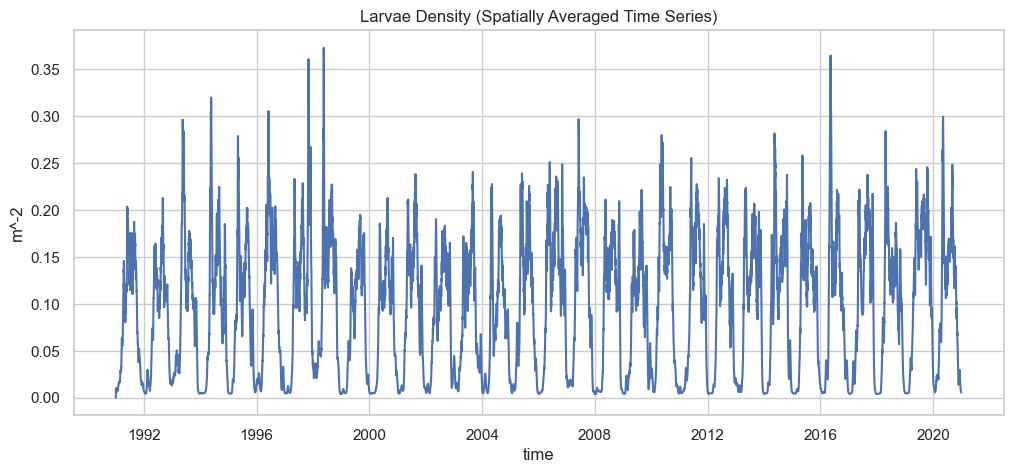

In [60]:
plot_temporal_series(ds_vector, var_name='larvae', title='Larvae Density', time_coords=time_values)

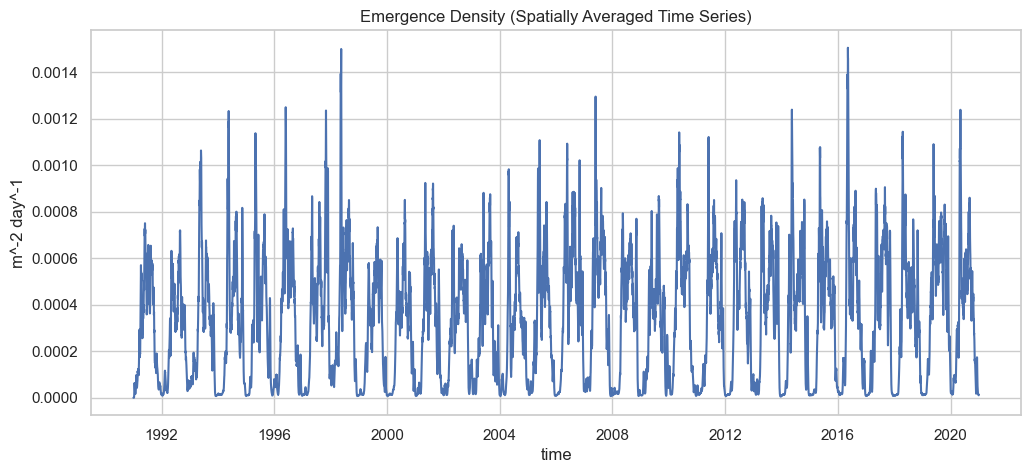

In [61]:
plot_temporal_series(ds_vector, var_name='emergence', title='Emergence Density', time_coords=time_values)

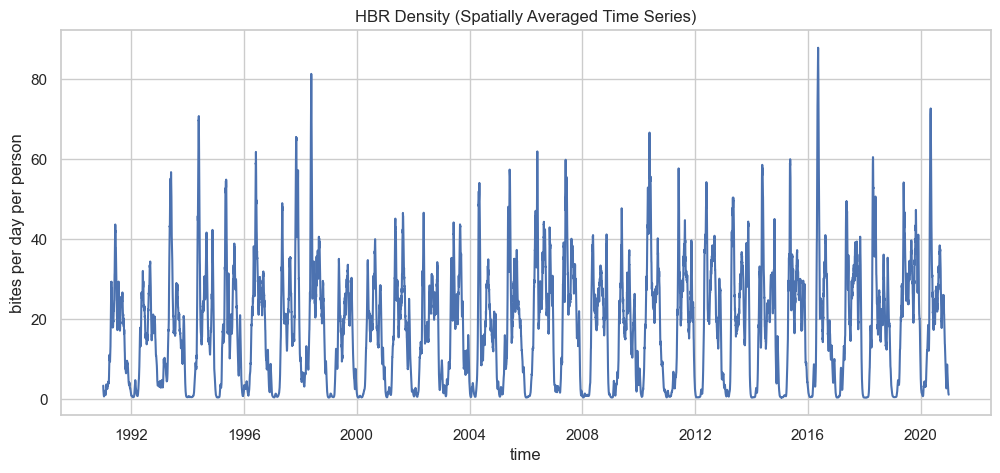

In [62]:
plot_temporal_series(ds_vector, var_name='hbr', title='HBR Density', time_coords=time_values)

In [63]:
try:
    ds_disease = xr.open_dataset(FILE_PATH, group="disease")
    print("Dataset loaded successfully.")
    print(ds_disease)
except Exception as e:
    print(f"Error loading dataset: {e}")

Dataset loaded successfully.
<xarray.Dataset> Size: 862MB
Dimensions:   (time: 10958, latitude: 57, longitude: 69)
Dimensions without coordinates: time, latitude, longitude
Data variables:
    PRd       (time, latitude, longitude) float32 172MB ...
    cspr      (time, latitude, longitude) float32 172MB ...
    eir       (time, latitude, longitude) float32 172MB ...
    cases     (time, latitude, longitude) float32 172MB ...
    immunity  (time, latitude, longitude) float32 172MB ...


In [64]:
if 'ds_disease' in locals():
    print("Dimensions:", dict(ds_disease.dims))
    print("\nVariables:", list(ds_disease.data_vars))
    
    # Check time range
    if 'time' in ds_disease.coords:
        print(f"\nTime Range: {ds_disease.time.min().values} to {ds_disease.time.max().values}")

Dimensions: {'time': 10958, 'latitude': 57, 'longitude': 69}

Variables: ['PRd', 'cspr', 'eir', 'cases', 'immunity']


C:\Users\yonas\AppData\Local\Temp\ipykernel_24832\1192351375.py:2: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print("Dimensions:", dict(ds_disease.dims))


## Disease Analysis (Transmission)
Analyzing variables related to disease transmission (e.g., EIR, PR, Cases).
*Variables*: `eir`, `pr`, `cases` (Hypothetical names).

### Entomological Inoculation Rate


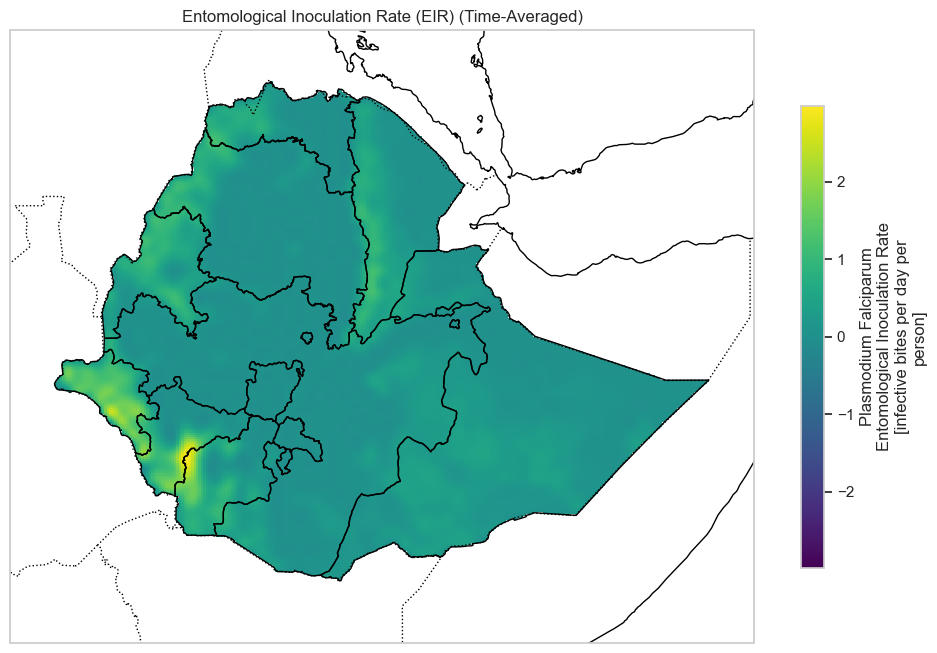

In [65]:
plot_spatial_map(ds_disease, 'eir', 'Entomological Inoculation Rate (EIR)',  lats=latitudes, lons=longitudes, shapefile_path=shapefile )

### Detectable parasite ratio

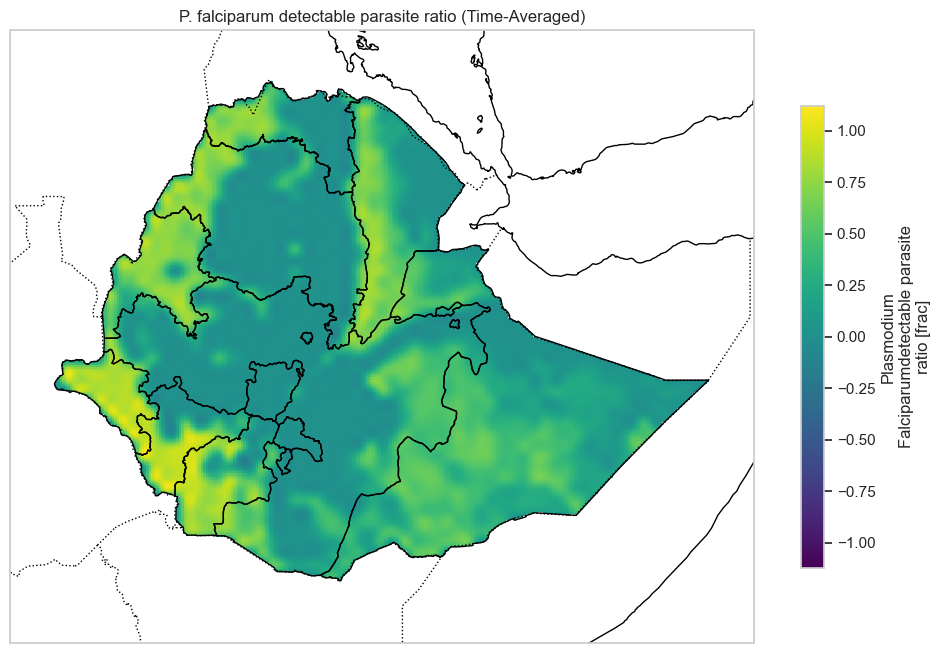

In [66]:
plot_spatial_map(ds_disease, 'PRd', 'P. falciparum detectable parasite ratio',  lats=latitudes, lons=longitudes, shapefile_path=shapefile)

### Circumsporozoite protein rate

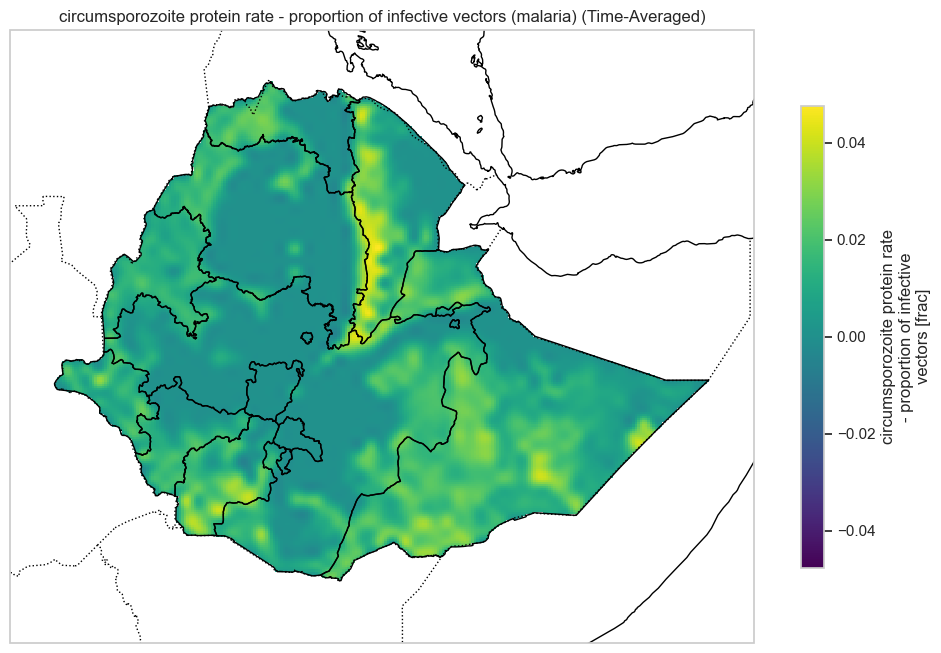

In [67]:
plot_spatial_map(ds_disease, 'cspr', 'circumsporozoite protein rate - proportion of infective vectors (malaria)',  lats=latitudes, lons=longitudes, shapefile_path=shapefile)

### Symptomatic cases (malaria)

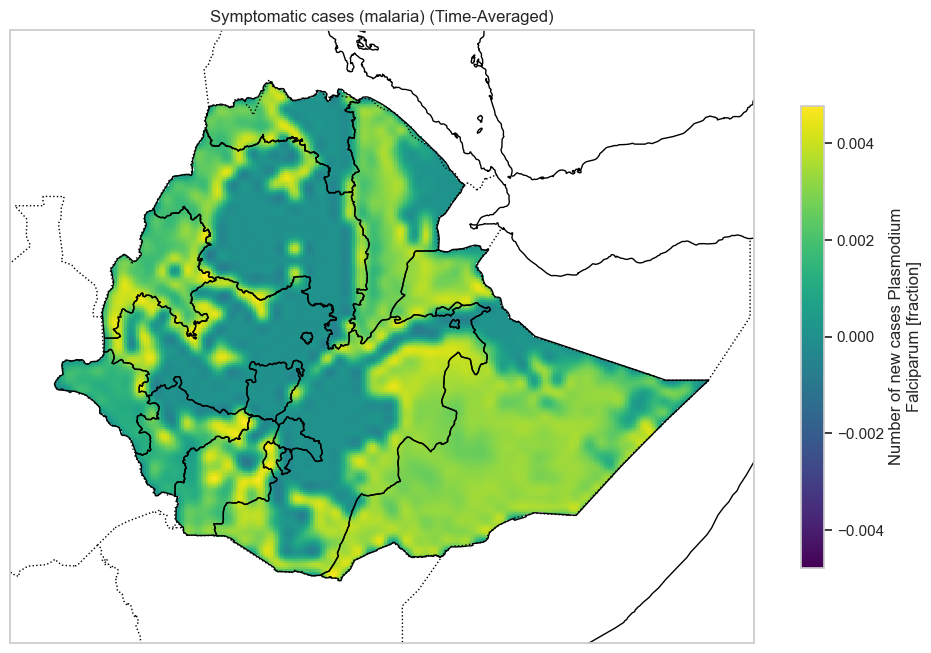

In [68]:
plot_spatial_map(ds_disease, 'cases', 'Symptomatic cases (malaria)',  lats=latitudes, lons=longitudes, shapefile_path=shapefile)

### Proportion of population with immunity (malaria)

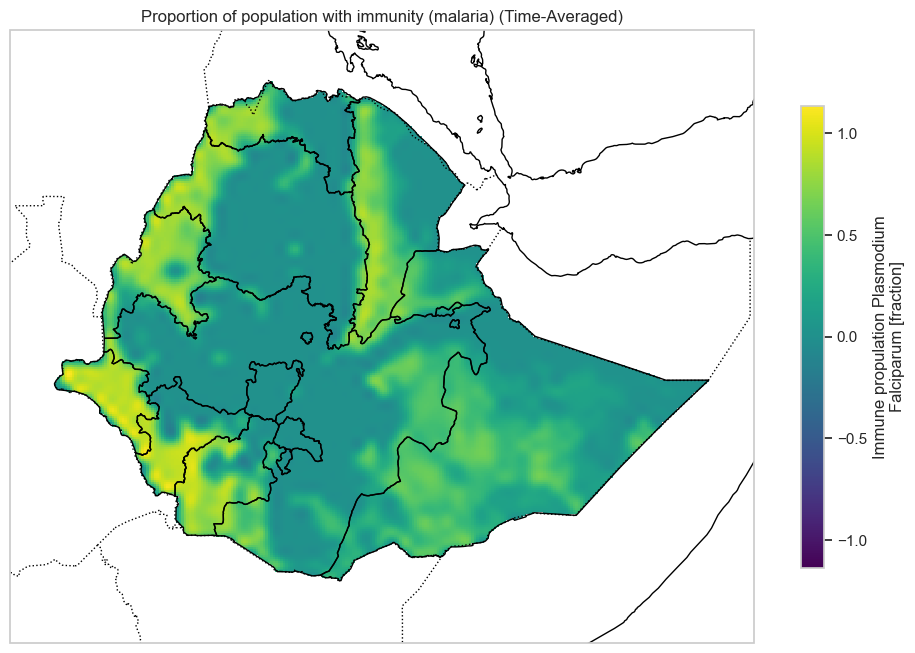

In [69]:
plot_spatial_map(ds_disease, 'immunity', 'Proportion of population with immunity (malaria)',  lats=latitudes, lons=longitudes, shapefile_path=shapefile)

### Fraction coverage temporary ponds

In [70]:
try:
    ds_hydrology = xr.open_dataset(FILE_PATH, group="hydrology")
    print("Dataset loaded successfully.")
    print(ds_hydrology)
except Exception as e:
    print(f"Error loading dataset: {e}")

Dataset loaded successfully.
<xarray.Dataset> Size: 172MB
Dimensions:  (latitude: 57, longitude: 69, time: 10958)
Dimensions without coordinates: latitude, longitude, time
Data variables:
    wperm    (latitude, longitude) float32 16kB ...
    wurbn    (latitude, longitude) float32 16kB ...
    wpond    (time, latitude, longitude) float32 172MB ...


In [71]:
if 'ds_hydrology' in locals():
    print("Dimensions:", dict(ds_hydrology.dims))
    print("\nVariables:", list(ds_hydrology.data_vars))
    
    # Check time range
    if 'time' in ds_hydrology.coords:
        print(f"\nTime Range: {ds_hydrology.time.min().values} to {ds_hydrology.time.max().values}")

Dimensions: {'latitude': 57, 'longitude': 69, 'time': 10958}

Variables: ['wperm', 'wurbn', 'wpond']


C:\Users\yonas\AppData\Local\Temp\ipykernel_24832\3651828559.py:2: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print("Dimensions:", dict(ds_hydrology.dims))


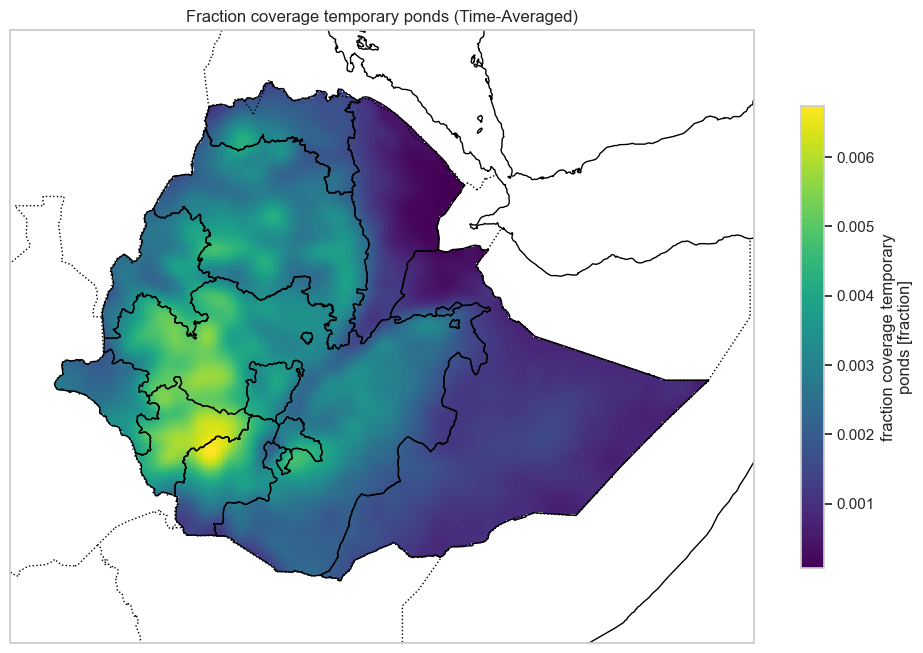

In [72]:
plot_spatial_map(ds_hydrology, 'wpond', 'Fraction coverage temporary ponds',  lats=latitudes, lons=longitudes, shapefile_path=shapefile)